In [83]:
import numpy as np
import rebound
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt

from plotting_params import use_my_style
use_my_style()

# Gas drag function in Python

## STEP 1: Convert ALL constants to AU, yr, M_sun units

In [84]:
kgtomsun = 1/1.989e30 #kg to solar mass
kb = 3.0898292661510003e-61 #boltzmann constant in sim units
mtoau = 6.6846e-12 #meter to au
jtos = 0.000954588 #jupiter mass to solar mass
stoyr = 1/(365.25*24*3600) 

R_char = 40 

r_pl = (100 * u.km).to('au').value # = 6.684587122268445e-07
solid_rho = (1000 * u.kg / u.m**3).to('M_sun/au3').value # = 1683721.7643842339
mu = 2.33
m_proton = const.m_p.to('M_sun').value # = 8.411856872862986e-58 
sigma_char = (2.7 * u.g / u.cm**2 ).to('M_sun/au2').value  # = 3.038845902395208e-07
lg = (5e-6 * u.kg / u.m**3).to('M_sun/au3').value # = 0.00841860882192117 
print(r_pl, lg)

6.684587122268445e-07 0.00841860882192117


## Initialise simulation

In [85]:
sim = rebound.Simulation()
sim.units = ('Msun', 'AU', 'yr')
G = sim.G
sim.add(m=0.965)
sim.move_to_com()

dists = np.linspace(1, 100, 100)
for i in dists:
    sim.add(m=0, a = i, f=0, e=0.5, r = r_pl)


sim.N_active = 1
print(sim.particles[1].ax)
sim.integrate(1)
print(sim.particles[1].ax)

0.0
-134.96987743354285


## Stopping time

In [31]:
def stopping_time(reb_sim):

    G = sim.G
    M_star = sim.particles[0].m 

    p_info = {'t_s': np.zeros(sim.N - sim.N_active), 'acc': np.array([[p.ax, p.ay, p.az] for p in sim.particles[sim.N_active:]]), 'semimajor': np.array([p.a for p in sim.particles[sim.N_active:]]), 'xy': np.zeros((sim.N - sim.N_active, 2))}

    for i, p in enumerate(sim.particles[sim.N_active:]):
        x, y, z = p.x, p.y, p.z
        vx, vy, vz = p.vx, p.vy, p.vz
        R = np.sqrt(x**2+y**2)

        # print('particle vs:', vx, vy, 'mag', np.sqrt(vx**2+vy**2))
        if p.a <= 0:
            print(f'skipped bc {p.a} smaller than 0')
            continue

        Omega = np.sqrt(G * M_star / R**3)

        T = 44 * (R / 22)**(-0.24) #from an Ideal testbed ... Bae et al. 2019 

        cs = np.sqrt(kb*T/(mu*m_proton))
        H = cs/Omega #in AU

        if H <= 0:
            print('skipped bc H')

            continue

        
        gas_surface_density = sigma_char * (R/R_char)**(-1) * np.exp(-R/R_char)
        #gas_surface_density = 1
        
        if R>=18 and R<=40:
            gas_surface_density *= 0.01
        
        gas_density = gas_surface_density / (np.sqrt(2*np.pi)* H) * np.exp(-z**2/(2*H**2))

        v_K = np.sqrt(G * M_star / R)
        theta = np.arctan2(y,x)
        v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0])
        # print(f'v_k is {v_K}')
        v_gas = v_K * v_unit_vector
        # print(f'v_gas {v_gas}')
        v_pl_vector = np.array([vx, vy, vz])
        v_rel = v_gas - v_pl_vector
        v_rel_mag = np.sqrt(v_rel[0]**2 + v_rel[1]**2 + v_rel[2]**2)

        # print('v_rel_mag', v_rel_mag)
        if v_rel_mag < 1e-60:
            print(f'skipped bc v_rel_mag is {v_rel_mag}')
            continue

        Re = 4 * r_pl * v_rel_mag / (cs * lg)

        if Re <= 0:
            print('skipped bc of Re')
            continue

        C_D = 24/Re * (1+0.27*Re)**(0.43)+ 0.47 * (1-np.exp(-0.04*Re**0.38))

        v_th = np.sqrt(8/np.pi) * cs
        # print(f'cd, {C_D}, vth, {v_th}')
        C_D_term = 3/8* v_rel_mag/v_th*C_D 
        # print(f'cd term {C_D_term}')
        ts = (gas_density / solid_rho * v_th / r_pl * min(1, C_D_term))**(-1)

        if ts < 0:
            print('skipped bc of ts')
            continue


        # print(ts)
        # print('re', Re)
        p_info['t_s'][i] = ts

        p_info['semimajor'][i] = p.a
        a = 1/ts[np.newaxis] * v_rel
        p.ax += a[0]
        p.ay += a[1]
        p.az += a[2]
        print('force implemented')
        #print(a[0], a[1], a[2])
        p_info['acc'][i] = [p.ax, p.ay, p.az]
        p_info['xy'][i] = [p.x, p.y]

    return p_info   

p_info = stopping_time(sim)
# sim.additional_forces = stopping_time
# sim.force_is_velocity_dependent = 1
print(p_info['t_s'])

force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force implemented
force impl

{'acc': array([145.14725908]), 'semimajor': array([1.])} 1.0


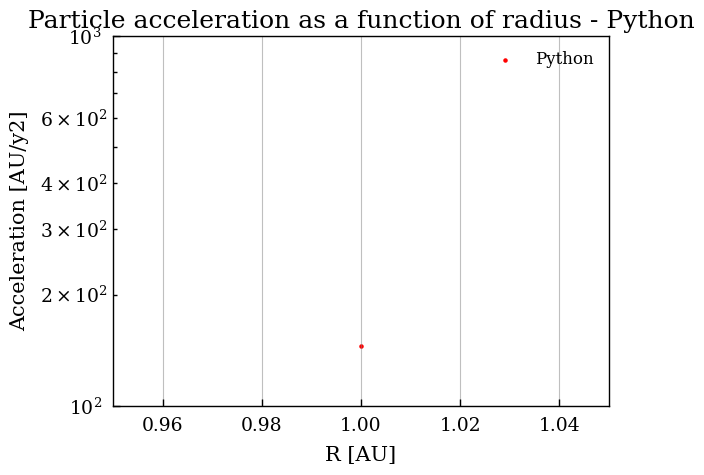

In [ ]:

p_info = {'acc': np.zeros(sim.N - sim.N_active), 'stopping_time': np.zeros(sim.N - sim.N_active),
          'semimajor': np.zeros(sim.N - sim.N_active)}

for i,p in enumerate(sim.particles[sim.N_active:]):
    accel = np.sqrt(p.ax**2 + p.ay**2 + p.az**2)

    p_info['acc'][i] = accel
    p_info['semimajor'][i] = p.a



/tmp/ipykernel_2078299/117023035.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


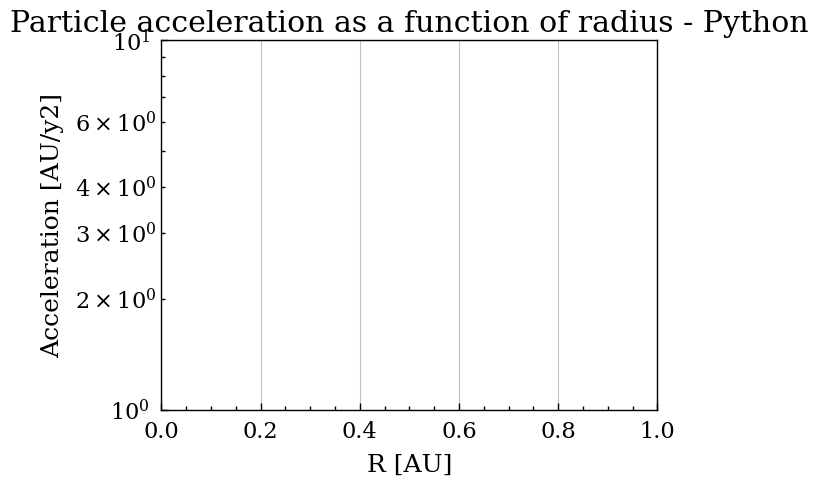

In [37]:

# plt.axvline(21, linestyle='--', label='PDS 70 b', color='orange')
# plt.axvline(34, linestyle='--', label='PDS 70 c', color='gold')

#plt.plot(Rs, stopping_time(Rs)[1], color='brown')
plt.yscale('log')
plt.xlabel('R [AU]')
plt.ylabel('Acceleration [AU/y2]')
plt.title('Particle acceleration as a function of radius - Python')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

## Just some unit checks

In [5]:
M_star = sim.particles[0].m

for p in sim.particles[sim.N_active:]:
    'grab particle properties from simulation'
    x, y, z = p.x, p.y, p.z
    vx, vy, vz = p.vx, p.vy, p.vz
    R = p.a  #because e = 0, but could we equally use R = sqrt(x**2 + y**2)?

    Omega = np.sqrt(G * M_star / R**3)

    T = 44 * (R / 22)**(-0.24) #from an Ideal testbed ... Bae et al. 2019 

    cs = np.sqrt(kb*T/(mu*m_proton))
    H = cs/Omega #in AU
    print(f'H is {H/R}')


    gas_surface_density = sigma_char * (R/R_char)**(-1) * np.exp(-R/R_char)

    'add a gap:'
    if R>=18 and R<=40:
        gas_surface_density *= 0.01

    gas_density = gas_surface_density / (np.sqrt(2*np.pi)* H) * np.exp(-z**2/(2*H**2))
    
    print('gas density', gas_density)
    print(gas_surface_density/(np.sqrt(2*np.pi)* H) )
    print('gas density', (gas_density*u.M_sun/u.AU**3).to('g/cm3'))
    print('surface density', (gas_surface_density*u.M_sun/u.AU**2).to('g/cm2'))

    'define gas velocity (for stopping time):'

    v_K = np.sqrt(G * M_star / R)
    theta = np.arctan2(y,x)
    v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0])

    v_gas = v_K * v_unit_vector
    v_pl_vector = np.array([vx, vy, vz])
    print(v_pl_vector, v_gas)
    v_rel = v_gas - v_pl_vector
    v_rel_mag = np.linalg.norm(v_rel)
    print('vrel', v_rel_mag)

    Re = 4 * r_pl * v_rel_mag / (cs * lg)

    C_D = 24/Re * (1+0.27*Re)**(0.43)+ 0.47 * (1-np.exp(-0.04*Re**0.38))
    print('cd', C_D)
    v_th = np.sqrt(8/np.pi) * cs

    C_D_term = 3/8* v_rel_mag/v_th*C_D 

    print('cd term', C_D_term)
    ts = (gas_density / solid_rho * v_th / r_pl * min(1, C_D_term))**(-1)

    print(f'{ts:.2e}')

    a = -1/ts * v_rel

    unit_A = (a*u.au/u.yr**2).to('m/Myr2')
    print('acc', unit_A)

H is 0.01955352588244
gas density 0.00024187795739179254
0.00024187795739179254
gas density 1.4365672672779846e-10 g / cm3
surface density 105.33347049905984 g / cm2
[ 2.63412445 10.18579636  0.        ] [2.28121869 5.73509157 0.        ]
vrel 4.464674184858568
cd 2045.4075560762012
cd term 17781.58353760208
2.42e+04
acc [ 2.18507323e+18  2.75572604e+19 -0.00000000e+00] m / Myr2


## Plotting just densities

In [ ]:
M_star = sim.particles[0].m

def densities(rr):

    Omega = np.sqrt(G * M_star / rr**3)

    T = 44 * (rr/ 22)**(-0.24) #from an Ideal testbed ... Bae et al. 2019 

    cs = np.sqrt(kb*T/(mu*m_proton))
    
    H = cs/Omega #in AU
    gas_surface_density = sigma_char * (rr/R_char)**(-1) * np.exp(-rr/R_char)

    gap_mask =(rr>=18) & (rr<=40)
    gas_surface_density[gap_mask] *= 0.01
    #print(f'H is {H}')
    gas_density = gas_surface_density / (np.sqrt(2*np.pi)* H) #* np.exp(-z**2/(2*H**2))

    return gas_surface_density, gas_density, H

Rs = np.linspace(0.1, 100, 1000)
surf_density = (densities(Rs)[0]*u.M_sun/u.AU**2).to('g/cm2')
density_3d = (densities(Rs)[1]*u.M_sun/u.AU**3).to('g/cm3')

fig, ax = plt.subplots(2, figsize=(10,9))

mytriad = [ "#562412", "#F0980A", "#B6770A", ]


ax[0].plot(Rs, surf_density, linewidth=3, color=mytriad[0])
ax[1].plot(Rs, density_3d, linewidth=3, color=mytriad[0])
#ax[2].plot(Rs, densities(Rs)[2]/Rs, color='darkgreen')
for i in range(2):
    ax[i].set_yscale('log')
    ax[i].axvline(21, linestyle='dotted', linewidth=3,  color=mytriad[1])
    ax[i].axvline(34, linestyle='dotted', linewidth=3,  color=mytriad[2])
    ax[i].grid(alpha=0.3)
    #ax[i].plot(Rs, densities(Rs)[-1])
    ax[i].legend()

ax[0].text(18, 11, 'PDS 70 b', rotation=90, color=mytriad[1], fontsize=12, va='bottom', ha='left')
ax[0].text(33.5, 11, 'PDS 70 c', rotation=90, color=mytriad[2], fontsize=12, va='bottom', ha='right')
ax[1].text(18, 10**-11, 'PDS 70 b', rotation=90, color=mytriad[1], fontsize=12, va='bottom', ha='left')
ax[1].text(33.5, 10**-11, 'PDS 70 c', rotation=90, color=mytriad[2], fontsize=12, va='bottom', ha='right')

ax[0].set_ylabel(r'surface density (g cm$^{-2}$)')
ax[1].set_ylabel(r'midplane density (g cm$^{-3}$)')

ax[1].set_xlabel('R [AU]')

#ax[2].set_ylabel(r'h = H/R')
plt.suptitle('Gas densities as a function of R', fontsize=24)
plt.tight_layout()
plt.savefig('plots/gas_densities.png')
plt.savefig('plots/gas_densities.pdf')


NameError: name 'plt' is not defined

# Gas drag function in C

In [27]:
import rebound
import reboundx
print(reboundx.__file__)
import numpy as np
import astropy.constants as const
import astropy.units as u
import sys
import reboundx
import time
import matplotlib.pyplot as plt
import math

jtos = const.M_jup / const.M_sun

R_b = 2.72 * const.R_jup.to('au').value
R_c = 2.04 * const.R_jup.to('au').value
R_star = 1.26 * const.R_sun.to('au').value
r_pl = (100 * u.km).to('au').value # = 6.684587122268445e-07

a_b, a_c, a_d = 21.1, 35.3, 10.7
e_b, e_c, e_d = 0.131, 0.033, 0.25
w_b, w_c, w_d = 191.4, 63, 29
i_b, i_c, i_d = 128.7, 128.5, 151
Omega_b, Omega_c, Omega_d = 174.3, 159.8, 144
m_b, m_c, m_d = 1.5, 3, 0.5

dtor = np.pi / 180
# --- create normal REBOUND simulation ---
sim = rebound.Simulation()
sim.units = ('Msun', 'AU', 'yr')
G = sim.G

sim.add(m=0.965)
sim.move_to_com()

dists = np.linspace(1,2,2)
for i in dists:
    sim.add(m=0, a = i, f=0, e=0.5, r = r_pl)

sim.N_active = 1

rebx = reboundx.Extras(sim)

myforce = rebx.load_force("test_force")     
rebx.add_force(myforce)


ModuleNotFoundError: No module named 'reboundx'

In [ ]:
times = np.linspace(0, 10, 100)
sim.integrate(100)

p_info_c = {'acc': np.zeros(sim.N - sim.N_active), 'semimajor': np.zeros(sim.N - sim.N_active)}

for i,p in enumerate(sim.particles[sim.N_active:]):
    accel = np.sqrt(p.ax**2 + p.ay**2 + p.az**2)
    p_info_c['acc'][i] = accel
    p_info_c['semimajor'][i] = p.a

# print('\n', p_info_c)


[17.12815592] [0.99656418]


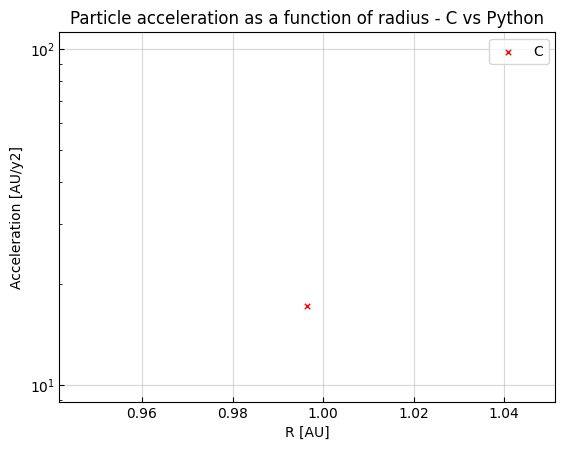

In [ ]:
fig, ax = plt.subplots()
print(p_info_c['acc'], p_info_c['semimajor'])
#print(p_info['acc'], p_info['semimajor'])
plt.scatter(p_info_c['semimajor'], p_info_c['acc'], color='red', marker='x', linewidths=1, label='C', s=15)
#plt.scatter(p_info['semimajor'], p_info['acc'], color='darkcyan', label='Python', s=5)
# plt.axvline(21, linestyle='--', label='PDS 70 b', color='orange')
# plt.axvline(34, linestyle='--', label='PDS 70 c', color='gold')
#plt.plot(Rs, stopping_time(Rs)[1], color='brown')
plt.yscale('log')
plt.xlabel('R [AU]')
plt.ylabel('Acceleration [AU/y2]')
plt.title('Particle acceleration as a function of radius - C vs Python')
plt.grid(alpha=0.5)
ax.tick_params(direction="in", which='both')
plt.legend()
plt.show()

In [ ]:
Nout = 10
times = np.linspace(0.,100000,1000)

N_particles = sim.N - sim.N_active

'''saving some stuff for plotting/diagnostics'''
semi_major = np.zeros((len(times), N_particles))
eccentricity = np.zeros((len(times), N_particles))
inclination = np.zeros((len(times), N_particles))

x_pos = np.zeros((len(times), N_particles))
y_pos = np.zeros((len(times), N_particles))
z_pos = np.zeros((len(times), N_particles))

# x_pos_pl = np.zeros((len(times), sim.N_active-1))
# y_pos_pl = np.zeros((len(times), sim.N_active-1))
# z_pos_pl = np.zeros((len(times), sim.N_active-1))
# inc_pl =  np.zeros((len(times), sim.N_active-1))
# a_pl =  np.zeros((len(times), sim.N_active-1))

tstart = time.time()
for i, t in enumerate(times):
    sim.integrate(t)
    # for pl in range(sim.N_active-1):
    #     planet = sim.particles[pl+1]
    #     x_pos_pl[i, pl] = planet.x 
    #     y_pos_pl[i, pl] = planet.y
    #     z_pos_pl[i, pl] = planet.z
    #     inc_pl[i, pl] = planet.inc
    #     a_pl[i, pl] = planet.a
    
    for j in range(N_particles):
        p = sim.particles[sim.N_active + j]
        if math.isnan(np.any([p.ax, p.ay, p.az])):
            print('error')
            break
        semi_major[i, j] = p.a
        eccentricity[i, j] = p.e
        if np.any(eccentricity > 1):
            print('particle ejected', eccentricity)
            break
        inclination[i, j] = p.inc
        x_pos[i, j] = p.x
        y_pos[i, j] = p.y
        z_pos[i, j] = p.z

tend = time.time()
print(f'{(tend - tstart)/60:.4f} min')


2.5033 min


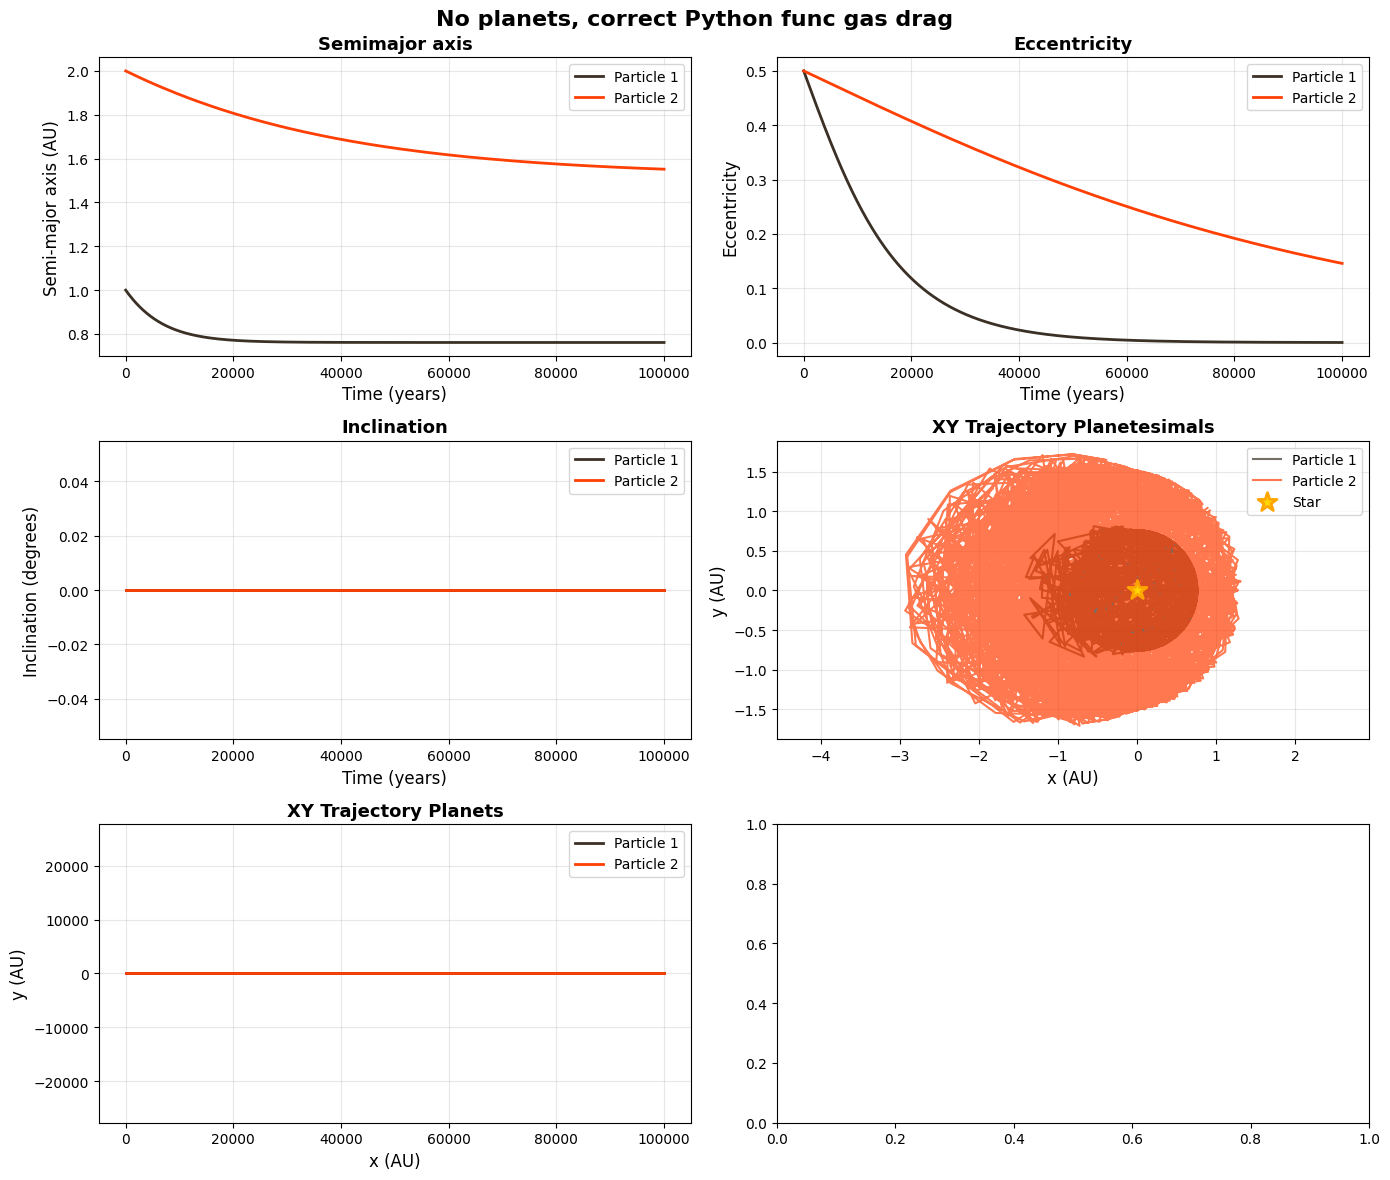

In [ ]:

#%%
# 
colors = ["#3B3025", "#FF3F04", '#FF5E5B']
c2 = ["#0F6A94", '#124559', "#91DCF3" ]
'''plotting a few different things'''
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# 1. Semi-major axis decayI
ax = axes[0, 0]
for j in range(N_particles):
    ax.plot(times, semi_major[:, j], color=colors[j], label=f'Particle {j+1}', linewidth=2)
    #ax.set_yscale('log')
# for i in range(sim.N_active-1):
#     ax.plot(times,a_pl[:, i], color=c2[i], label=f'Planet {i+1}', linewidth=2)

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Semi-major axis (AU)', fontsize=12)
ax.set_title('Semimajor axis', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Eccentricity damping
ax = axes[0, 1]
for j in range(N_particles):
    ax.plot(times, eccentricity[:, j], color=colors[j], label=f'Particle {j+1}', linewidth=2)
ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Eccentricity', fontsize=12)
ax.set_title('Eccentricity', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Inclination damping
ax = axes[1, 0]
for j in range(N_particles):
   ax.plot(times, np.degrees(inclination[:, j]), color=colors[j], label=f'Particle {j+1}', linewidth=2)
# for i in range(sim.N_active-1):
#     ax.plot(times, np.degrees(inc_pl[:, i]), color=c2[i], label=f'Planet {i+1}', linewidth=2)

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Inclination (degrees)', fontsize=12)
ax.set_title('Inclination', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 5. xy trajectory
ax = axes[1, 1]
for j in range(N_particles):
    ax.plot(x_pos[:, j], y_pos[:, j], color=colors[j], label=f'Particle {j+1}', alpha=0.7)
    # ax.scatter(x_pos[0, j], y_pos[0, j], s=100, marker='o', zorder=5)
    # ax.scatter(x_pos[-1, j], y_pos[-1, j], s=100, marker='x', zorder=5)
ax.scatter(0, 0, s=200, marker='*', color='gold', edgecolors='orange', 
          linewidths=2, label='Star', zorder=10)
ax.set_xlabel('x (AU)', fontsize=12)
ax.set_ylabel('y (AU)', fontsize=12)
ax.set_title('XY Trajectory Planetesimals', fontsize=13, fontweight='bold')
ax.axis('equal')
ax.legend()
ax.grid(alpha=0.3)


# 6. Vertical motion (z)
ax = axes[2, 0]
for j in range(N_particles):
    ax.plot(times, z_pos[:, j], color=colors[j], label=f'Particle {j+1}', linewidth=2)
# for i in range(sim.N_active -1):
#     ax.plot(times, z_pos_pl[:, j], color=c2[i], label=f'Planet {i+1}', linewidth=2)

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('z (AU)', fontsize=12)
ax.set_title('Height (z) from plane', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)


#ax = axes[2,1]
#for j in range(3):
#    ax.plot(x_pos_pl[:, j], y_pos_pl[:, j], color=c2[j], label=f'Planet {j+1}', alpha=0.7)
    # ax.scatter(x_pos[0, j], y_pos[0, j], s=100, marker='o', zorder=5)
    # ax.scatter(x_pos[-1, j], y_pos[-1, j], s=100, marker='x', zorder=5)
# ax.scatter(0, 0, s=200, marker='*', color='gold', edgecolors='orange', 

#           linewidths=2, label='Star', zorder=10)
ax.set_xlabel('x (AU)', fontsize=12)
ax.set_ylabel('y (AU)', fontsize=12)
ax.set_title('XY Trajectory Planets', fontsize=13, fontweight='bold')
ax.axis('equal')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(r'No planets, correct Python func gas drag', fontsize=16, fontweight='bold')
plt.tight_layout()
#plt.savefig('gas_drag_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Just calculating stopping time - no integration

In [47]:
# sim2 = rebound.Simulation()
# sim2.units = ('Msun', 'AU', 'yr')
# G = sim2.G
# sim2.add(m=0.965)
# sim2.move_to_com()

dists = np.linspace(1, 200, 151)
# # for i in dists:
# #     sim2.add(m=0, a = i, f=0, e=0.1, r = r_pl)

# sim2.N_active = 1

def stopping_time_calc(ecc):

    simulation = rebound.Simulation()
    simulation.units = ('Msun', 'AU', 'yr')
    G = simulation.G
    simulation.add(m=0.965)
    simulation.move_to_com()

    simulation.N_active = 1

    for i in dists:
        simulation.add(m=0, a = i, f=0, e=ecc, r = r_pl)

    G = simulation.G
    M_star = simulation.particles[0].m 

    p_info = {'t_s1': np.zeros(simulation.N - simulation.N_active),
              #'t_s2': np.zeros(simulation.N - simulation.N_active),
              'acc': np.array([[p.ax, p.ay, p.az] for p in simulation.particles[simulation.N_active:]]),
              'semi': np.array([p.a for p in simulation.particles[simulation.N_active:]]),
              'dist': np.zeros(simulation.N - simulation.N_active),
              'xy': np.zeros((simulation.N - simulation.N_active, 2))}

    for i, p in enumerate(simulation.particles[simulation.N_active:]):
        
        x, y, z = p.x, p.y, p.z
        vx, vy, vz = p.vx, p.vy, p.vz
        R = np.sqrt(x**2+y**2)
        p_info['dist'][i] = R
        # print('particle vs:', vx, vy, 'mag', np.sqrt(vx**2+vy**2))
        if p.a <= 0:
            print(f'skipped bc {p.a} smaller than 0')
            continue

        Omega = np.sqrt(G * M_star / R**3)

        T = 44 * (R / 22)**(-0.24) #from an Ideal testbed ... Bae et al. 2019 

        cs = np.sqrt(kb*T/(mu*m_proton))
        H = cs/Omega #in AU

        if H <= 0:
            print('skipped bc H')

            continue

        gas_surface_density = sigma_char * (R/R_char)**(-1) * np.exp(-R/R_char)
        #gas_surface_density = 1
        
        if R>=18 and R<=40:
            gas_surface_density *= 0.01
        
        gas_density = gas_surface_density / (np.sqrt(2*np.pi)* H) * np.exp(-z**2/(2*H**2))

        v_K = np.sqrt(G * M_star / R)
        theta = np.arctan2(y,x)
        v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0])
        # print(f'v_k is {v_K}')
        v_gas = v_K * v_unit_vector
        # print(f'v_gas {v_gas}')
        v_pl_vector = np.array([vx, vy, vz])
        v_rel = v_gas - v_pl_vector

        v_rel_mag = np.sqrt(v_rel[0]**2 + v_rel[1]**2 + v_rel[2]**2)

        Re = 4 * r_pl * v_rel_mag / (cs * lg)

        C_D = 24/Re * (1+0.27*Re)**(0.43)+ 0.47 * (1-np.exp(-0.04*Re**0.38))
        #C_D_2 = 24/Re2 * (1+0.27*Re2)**(0.43)+ 0.47 * (1-np.exp(-0.04*Re2**0.38))
        
        v_th = np.sqrt(8/np.pi) * cs
        # print(f'cd, {C_D}, vth, {v_th}')
        C_D_term = 3/8* v_rel_mag/v_th*C_D 
        #C_D_term2 = 3/8* v_rel_mag_2/v_th*C_D_2

        # print(f'cd term {C_D_term}')
        ts1 = (gas_density / solid_rho * v_th / r_pl * min(1, C_D_term))**(-1)

        p_info['t_s1'][i] = ts1

        p_info['xy'][i] = [p.x, p.y]

    return p_info

p_info = [stopping_time_calc(ecc) for ecc in [0.1, 0.3, 0.5, 0.7, 0.9]]
pinfo05 = stopping_time_calc(0.5)

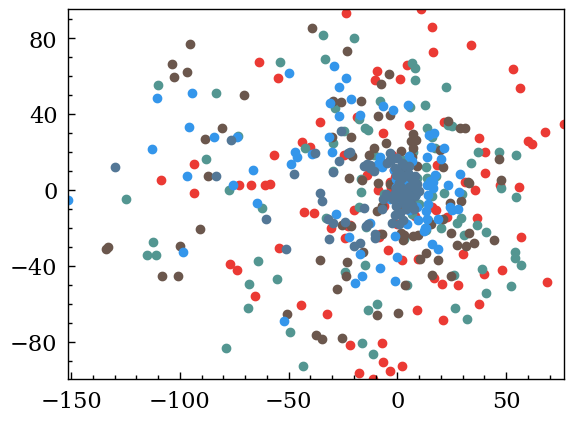

In [21]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots()
for i in range(len(p_info)):
    plt.scatter(p_info[i]['xy'][:,0], p_info[i]['xy'][ :,1], label=f'e={ [0.1, 0.3, 0.5, 0.7, 0.8, 0.9][i]}')
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))


In [42]:
print(pinfo05['dist'])

[  0.57110589   1.41661904   1.73827551   2.37398051   6.27866837
   2.98559771   6.91932054   7.05010481  11.64666401   5.07408253
   5.82874956   8.77469836  18.48402363   8.24160339   7.70318281
   9.30914025   9.10567375  18.92148393  17.99239299  20.0121294
  11.48135681  25.39436575  12.4534044   35.64201195  26.44329649
  12.87633281  16.26841663  26.37532405  16.73148349  17.23671623
  21.38924303  47.35407508  44.3857428   24.58588787  22.67030324
  18.32437507  53.59017525  31.31870864  20.59946587  48.36330967
  43.21921767  23.37255255  62.92090936  56.23600703  66.31246709
  24.89030656  23.50611142  49.26851002  32.71578366  56.06554677
  26.22374835  40.79563362  26.91684646  28.66313431  29.78059811
  82.91084215  71.8996049   70.43869571  37.80182406  40.40295141
  30.43709359  74.45703142  75.98285226  51.47962937  46.49317247
  38.58961725  51.09401737  66.60716851  88.88207145  85.74407088
  91.07207945  89.57128148  59.34715855 107.24723281  40.41599588
  39.199495

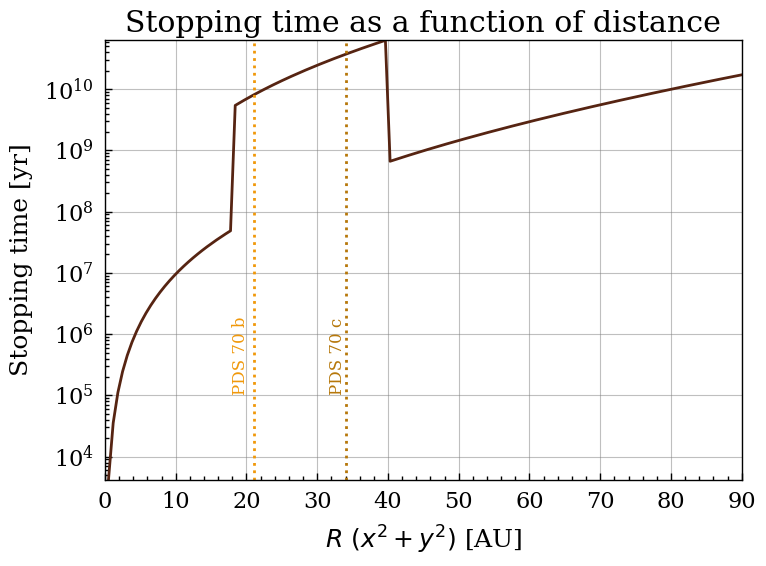

In [81]:
#plt.plot(pinfo['semimajor'], pinfo['t_s2'], color='navy', label='approx')

fig,ax = plt.subplots(figsize=(8,6))

c1 = "#562412"
c2 = "#F0980A"
c3 = "#B6770A"
# for i in range(len(p_info)):
#     plt.scatter(p_info[i]['dist'], p_info[i]['t_s1'], s=5, label=f'e={ [0.1, 0.3, 0.5, 0.7, 0.9][i] }')

plt.plot(pinfo05['dist'], pinfo05['t_s1'], color=c1,  linewidth=2)
    #ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
    #ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.axvline(21, linestyle=':', linewidth=2,color=c2)
plt.axvline(34, linestyle=':', linewidth=2,color=c3)
#plt.plot(Rs, stopping_time(Rs)[1], color='brown')
plt.yscale('log')
plt.xlabel(r'$R$ $(x^2+y^2)$ [AU]')
#plt.xlabel(r'$a$ [AU]')
plt.text(18, 1e5, 'PDS 70 b', rotation=90, color=c2, fontsize=12, va='bottom', ha='left')
plt.text(34, 1e5, 'PDS 70 c', rotation=90, color=c3, fontsize=12, va='bottom', ha='right')
plt.xlim(0,90)
plt.ylabel('Stopping time [yr]')
plt.title('Stopping time as a function of distance')
plt.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('plots/stopping_time.png', dpi=150)
plt.savefig('plots/stopping_time.pdf')

## Animation

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

orange_colours = ["#FA5812", "#F77852", '#FF5E5B']
blue_colours = ["#0F6A94", '#124559', "#91DCF3" ]

lines_planetesimals = [ax.plot([], [], [], lw=1, alpha=0.5, color=orange_colours[i])[0] for i in range(3)]
points_planetesimals = [ax.plot([], [], [], 'o', alpha=0.5, color=orange_colours[i], markersize=3)[0] for i in range(3)]

lines_planets = [ax.plot([], [], [], lw=1, color=blue_colours[i])[0] for i in range(3)]
points_planets = [ax.plot([], [], [], 'o', color=blue_colours[i], markersize=8)[0] for i in range(3)]

labels_planetesimals = [f"Planetesimal {i+1}" for i in range(3)]
labels_planets = [f"Planet {i}" for i in ['d', 'b', 'c']]

legend_elements = (
    [Line2D([0], [0], color=c, lw=2, label=label)
     for c, label in zip(orange_colours, labels_planetesimals)] +
    [Line2D([0], [0], color=c, lw=2, label=label)
     for c, label in zip(blue_colours, labels_planets)]
)

ax.legend(handles=legend_elements, loc='upper left', frameon=False)

ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlim(min(x_pos.min(), x_pos_pl.min()), max(x_pos.max(), x_pos_pl.max()))
ax.set_ylim(min(y_pos.min(), y_pos_pl.min()), max(y_pos.max(), y_pos_pl.max()))
ax.set_zlim(min(z_pos.min(), z_pos_pl.min()), max(z_pos.max(), z_pos_pl.max()))

ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")
ax.set_zlabel("Z (AU)")
ax.set_title("Planetesimals (orange) and Planets (blue)")

def update(i):
    # Planetesimals
    for p in range(3):
        lines_planetesimals[p].set_data(x_pos[:i, p], y_pos[:i, p])
        lines_planetesimals[p].set_3d_properties(z_pos[:i, p])

        points_planetesimals[p].set_data([x_pos[i, p]], [y_pos[i, p]])
        points_planetesimals[p].set_3d_properties([z_pos[i, p]])

    # Planets
    for p in range(3):
        lines_planets[p].set_data(x_pos_pl[:i, p], y_pos_pl[:i, p])
        lines_planets[p].set_3d_properties(z_pos_pl[:i, p])

        points_planets[p].set_data([x_pos_pl[i, p]], [y_pos_pl[i, p]])
        points_planets[p].set_3d_properties([z_pos_pl[i, p]])

    return (
        lines_planetesimals + points_planetesimals +
        lines_planets + points_planets
    )

ani = FuncAnimation(fig, update, frames=range(0, len(x_pos), 5), interval=20, blit=False)
ani.save('animations/gas_drag_other_ptcls.gif', fps=1000, writer='pillow' )
plt.show()
